# 🚴 Berlin Bicycle Accident Analysis
### Capstone Project — Data Science Bootcamp

**Goal:** Analyze 8 years of official German traffic accident data (2018–2025) to identify risk patterns for cyclists in Berlin and build a machine learning model to predict accident severity.

**Data source:** [Unfallatlas](https://unfallatlas.statistikportal.de) — Federal Statistical Office of Germany  
**Scope:** 37,948 bicycle accidents in Berlin across 12 districts  
**Tech stack:** `pandas` · `seaborn` · `folium` · `XGBoost` · `OSMnx` · `Streamlit`

---

## Table of Contents
1. [Data Loading & Merging](#1-data-loading)
2. [Filtering & Cleaning](#2-filtering)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Collision Partner Analysis](#4-collision)
5. [Temporal Analysis](#5-temporal)
6. [District Risk Analysis](#6-district)
7. [Geospatial Heatmap](#7-heatmap)


---
## 1. Data Loading & Merging <a id='1-data-loading'></a>

We load 10 years of Unfallatlas CSV/TXT files (2016–2025), excluding auxiliary `LinRef` geometry files. Each file covers one calendar year for all of Germany.


In [1]:
import glob
import os
import pandas as pd

folder_path = "data"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

# Exclude LinRef geometry files and any previously generated output files
all_file_paths = [
    f for f in csv_files + txt_files
    if "LinRef" not in f and "berlin" not in f.lower()
]
column_mapping = {
    # Road conditions — 3 different names across years
    "IstStrasse":         "STRZUSTAND",
    "STRZUSTAND":         "STRZUSTAND",
    "IstStrassenzustand": "STRZUSTAND",
    
    # Light conditions
    "LICHT":              "ULICHTVERH",
    
    # Other mappings
    "IstSonstig":         "IstSonstige",
    "UIDENTSTLAE":        "UIDENTSTLA",
    "OBJECTID_1":         "OBJECTID",
    "ujahr":              "UJAHR",
    "istrad":             "IstRad",
    "ISTRAD":             "IstRad",
}
df_list = []

for file_path in all_file_paths:
    file_name = os.path.basename(file_path)
    try:
        # Fixed: removed low_memory=False to prevent Python engine conflict
        temp_df = pd.read_csv(
                   file_path, sep=";", encoding="utf-8-sig"

        )

        # Standardize column names
        temp_df = temp_df.rename(columns=column_mapping)
        temp_df["source_file"] = file_name

        df_list.append(temp_df)

        # Check year information
        year_info = (
            temp_df["UJAHR"].unique().tolist()
            if "UJAHR" in temp_df.columns
            else "No Year Column!"
        )
        print(f"✅ {file_name} — {len(temp_df)} rows — Year: {year_info}")

    except Exception as e:
        print(f"❌ {file_name} — ERROR: {e}")

# Merge all DataFrames
df= pd.concat(df_list, ignore_index=True)

# Clean Year column
if "UJAHR" in df.columns:
    df["UJAHR"] = (
        df["UJAHR"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
    )

print("\n" + "=" * 45)

print(f"\n✅ Data merged and columns standardized successfully!")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"Merged Years: {sorted(df['UJAHR'].unique())}")
print("=" * 45)




/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_4377/3409940271.py:38: DtypeWarning: Columns (0: UIDENTSTLAE) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


✅ Unfallorte2024.csv — 268519 rows — Year: [2024]
✅ Unfallorte_2025.csv — 273007 rows — Year: [2025]
✅ Unfallorte2023.csv — 269048 rows — Year: [2023]
✅ Unfallorte2022.csv — 256492 rows — Year: [2022]
✅ Unfallorte2020.csv — 237994 rows — Year: [2020]


/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_4377/3409940271.py:38: DtypeWarning: Columns (0: UIDENTSTLA) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


✅ Unfallorte2017.txt — 195229 rows — Year: [2017]
✅ Unfallorte.txt — 151673 rows — Year: [2016]
✅ Unfallorte_2021.txt — 238826 rows — Year: [2021]
✅ Unfallorte2019.txt — 268370 rows — Year: [2019]
✅ Unfallorte2018.txt — 211868 rows — Year: [2018]


✅ Data merged and columns standardized successfully!
Total Rows: 2371026
Total Columns: 29
Merged Years: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


### 1.1 Schema Drift Across Annual Releases

The ten annual Unfallatlas releases do not share a single schema. Only **19 of
29 columns** are present in all ten files. Field names were harmonised against
the official *Datensatzbeschreibung* (DSB) before merging — see `column_mapping`
in the cell above.

| Release | Road surface | Light | Other participant | Truck | Accident ID | Row ID (ArcGIS) | Police unit |
|---|---|---|---|---|---|---|---|
| 2016 | `IstStrasse` | `ULICHTVERH` | `IstSonstig` | `IstGkfz` | — | `FID`, `OBJECTID` | — |
| 2017 | `STRZUSTAND` | **`LICHT`** | `IstSonstig` | **absent** | `UIDENTSTLA` | `OBJECTID` | — |
| 2018 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstig` | `IstGkfz` | — | `OBJECTID_1` | — |
| 2019 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | — | `OBJECTID` | — |
| 2020 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OBJECTID` | — |
| 2021 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | — |
| 2022 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OBJECTID` | — |
| 2023 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | `PLST` |
| 2024 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | `PLST` |
| 2025 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | — | `PLST` |

**Consequences for this analysis**

1. **Road surface condition** is published under three different names
   (`IstStrasse` → `STRZUSTAND` → `IstStrassenzustand`). Without harmonisation,
   `pd.concat` would create three half-empty columns instead of one.
2. **Light conditions** are named `LICHT` in the 2017 release only.
3. **Truck involvement** (`IstGkfz`) is missing from the 2017 release. This does
   not affect the Berlin subset, which starts in 2018.
4. **There is no cross-year unique accident identifier.** `UIDENTSTLA` is absent
   from the 2018 and 2019 releases, so it cannot serve as a deduplication key.
   Instead, integrity was verified by row-count reconciliation: the sum of rows
   across the ten files (2,371,026) matches the merged DataFrame exactly, and
   each file contributes exactly one calendar year. Duplication is therefore
   ruled out by construction.
5. `FID`, `OBJECTID`, `OBJECTID_1` and `OID_` are per-file ArcGIS row numbers.
   They are not stable across releases and carry no analytical meaning, so they
   are dropped rather than harmonised.
6. `PLST` (recording police unit) exists only from 2023 onwards and is not used.

**Encoding and delimiter.** All ten files are semicolon-delimited and valid
UTF-8. Four of them (2021, 2023, 2024, 2025) carry a UTF-8 byte-order mark, so
all files are read with `encoding="utf-8-sig"`, which strips the BOM where
present and is a no-op otherwise. Reading with `latin-1` would silently corrupt
the first column name in those four files without raising an error.

---
## 2. Filtering & Cleaning <a id='2-filtering'></a>

We apply two filters to isolate our target population:
- **`IstRad == 1`** — accidents involving at least one bicycle
- **`ULAND == 11`** — federal state code for Berlin

> **Note:** Berlin only appears in the dataset from 2018 onwards — prior years were not submitted to the Unfallatlas system.


> **Coverage note:** Berlin enters the Unfallatlas with the 2018 release.
> Verified directly: the 2016 and 2017 files contain zero rows with
> `ULAND == 11`. The analysis window is therefore 2018–2025 (8 years).
>
> This also matters for any Germany-wide time series: national row counts rise
> 77% between 2016 and 2019 (151,673 → 268,370) and then plateau. That rise
> reflects federal states being added to the dataset, not a rise in accidents.
> The Berlin subset is unaffected — its yearly counts are stable
> (11,309–13,652).

In [2]:
# Filter: bicycle accidents only
df_combined = df[df['IstRad'] == 1]
print(f"Total bicycle accidents (Germany): {len(df_combined):,}")

# Filter: Berlin (ULAND = 11)
df_berlin = df_combined[df_combined['ULAND'] == 11]
print(f"Berlin bicycle accidents:          {len(df_berlin):,}")

print("\nAccidents per year in Berlin:")
print(df_berlin['UJAHR'].value_counts().sort_index())

print("\nAccident severity distribution (UKATEGORIE):")
print(df_berlin['UKATEGORIE'].value_counts().rename({1:'Fatal', 2:'Serious injury', 3:'Minor injury'}))


Total bicycle accidents (Germany): 716,365
Berlin bicycle accidents:          37,948

Accidents per year in Berlin:
UJAHR
2018    5192
2019    5005
2020    5109
2021    4293
2022    4658
2023    4472
2024    4452
2025    4767
Name: count, dtype: int64

Accident severity distribution (UKATEGORIE):
UKATEGORIE
Minor injury      33018
Serious injury     4856
Fatal                74
Name: count, dtype: int64


### 2.1 Column Selection & Renaming

We retain only the 16 columns relevant to our analysis and rename them from German abbreviations to descriptive English names.

| Original | Renamed | Description |
|---|---|---|
| UJAHR | year | Accident year |
| UMONAT | month | Month (1–12) |
| USTUNDE | hour | Hour of day (0–23) |
| UWOCHENTAG | day_of_week | Day of week (1=Sun, 7=Sat) |
| UKATEGORIE | accident_severity | 1=Fatal, 2=Serious, 3=Minor |
| ULICHTVERH | light_conditions | 0=Daylight, 1=Twilight, 2=Darkness |
| UART       | accident_kind    | Collision configuration (codes 0–9) |
| UTYP1      | accident_subtype | Conflict mechanism / accident type (codes 1–7) |
| STRZUSTAND | road_conditions | 0=Dry, 1=Wet, 2=Ice/Snow |
| IstPKW | is_car | Car involved (0/1) |
| IstFuss | is_pedestrian | Pedestrian involved (0/1) |
| IstKrad | is_motorcycle | Motorcycle involved (0/1) |
| IstGkfz | is_truck | Heavy vehicle involved (0/1) |
| UKREIS | district_code | Berlin district (1–12) |
| XGCSWGS84 | longitude | WGS84 longitude |
| YGCSWGS84 | latitude | WGS84 latitude |

All categorical codes were verified against the official Unfallatlas
Datensatzbeschreibung (DSB), included in `docs/DSB_Unfallatlas.pdf`.

In [3]:
import glob
import os
import csv as csvmod

import pandas as pd

folder_path = "data"

all_file_paths = sorted(
    f for f in glob.glob(os.path.join(folder_path, "*.csv"))
    + glob.glob(os.path.join(folder_path, "*.txt"))
    if "LinRef" not in f and "berlin" not in f.lower()
)

# Byte sequences that appear when UTF-8 text is decoded as latin-1/cp1252.
MOJIBAKE_MARKERS = ['Ã¤', 'Ã¶', 'Ã¼', 'ÃŸ', 'Ã„', 'Ã–', 'Ãœ', 'ï»¿', 'Â']

BOMS = {
    'utf-8-sig':  b'\xef\xbb\xbf',
    'utf-16-le':  b'\xff\xfe',
    'utf-16-be':  b'\xfe\xff',
}

report = []

for path in all_file_paths:
    name = os.path.basename(path)
    raw = open(path, 'rb').read()

    # 1. BOM detection
    bom = next((label for label, sig in BOMS.items() if raw.startswith(sig)), 'none')

    # 2. Is the file valid strict UTF-8? If yes, it IS utf-8 (or plain ASCII).
    try:
        raw.decode('utf-8')
        valid_utf8 = True
    except UnicodeDecodeError:
        valid_utf8 = False

    # 3. Is it pure ASCII? Then encoding is irrelevant for this file.
    is_ascii = all(b < 128 for b in raw)

    # 4. What does the current (latin-1) read produce? Look for mojibake.
    as_latin1 = raw.decode('latin-1')
    mojibake = [m for m in MOJIBAKE_MARKERS if m in as_latin1]

    # 5. Delimiter, detected from the header line rather than guessed
    header_line = as_latin1.split('\n', 1)[0]
    try:
        sep = csvmod.Sniffer().sniff(header_line, delimiters=';,\t|').delimiter
    except csvmod.Error:
        sep = '?'

    # 6. Recommended encoding
    if bom == 'utf-8-sig':
        recommended = 'utf-8-sig'
    elif is_ascii:
        recommended = 'ascii (any works)'
    elif valid_utf8:
        recommended = 'utf-8'
    else:
        recommended = 'cp1252'

    report.append({
        'file': name,
        'size_kb': round(len(raw) / 1024),
        'bom': bom,
        'pure_ascii': is_ascii,
        'valid_utf8': valid_utf8,
        'sep': repr(sep),
        'mojibake_in_latin1': ', '.join(mojibake) or '-',
        'recommended': recommended,
    })

report_df = pd.DataFrame(report)
pd.set_option('display.max_colwidth', 40)
print(report_df.to_string(index=False))

               file  size_kb       bom  pure_ascii  valid_utf8 sep mojibake_in_latin1       recommended
     Unfallorte.txt    21478      none        True        True ';'                  - ascii (any works)
 Unfallorte2017.txt    30104      none        True        True ';'                  - ascii (any works)
 Unfallorte2018.txt    28755      none        True        True ';'                  - ascii (any works)
 Unfallorte2019.txt    36427      none        True        True ';'                  - ascii (any works)
 Unfallorte2020.csv    37176      none        True        True ';'                  - ascii (any works)
 Unfallorte2022.csv    40073      none        True        True ';'                  - ascii (any works)
 Unfallorte2023.csv    42564 utf-8-sig       False        True ';'                ï»¿         utf-8-sig
 Unfallorte2024.csv    42481 utf-8-sig       False        True ';'                ï»¿         utf-8-sig
Unfallorte_2021.txt    37087 utf-8-sig       False        True '

In [4]:

# Select relevant columns
columns_to_keep = [
    'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG',
    'UKATEGORIE', 'UART', 'UTYP1',
    'ULICHTVERH', 'STRZUSTAND',
    'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz',
    'UKREIS', 'XGCSWGS84', 'YGCSWGS84'
]

df_clean = df_berlin[columns_to_keep].copy()

# Rename to English
df_clean = df_clean.rename(columns={
    'UJAHR': 'year', 'UMONAT': 'month', 'USTUNDE': 'hour',
    'UWOCHENTAG': 'day_of_week', 'UKATEGORIE': 'accident_severity',
    'UART': 'accident_kind', 'UTYP1': 'accident_subtype',
    'ULICHTVERH': 'light_conditions', 'STRZUSTAND': 'road_conditions',
    'IstPKW': 'is_car', 'IstFuss': 'is_pedestrian',
    'IstKrad': 'is_motorcycle', 'IstGkfz': 'is_truck',
    'UKREIS': 'district_code', 'XGCSWGS84': 'longitude', 'YGCSWGS84': 'latitude'
})

# Fix coordinate format (German decimal comma → dot)
for col in ['longitude', 'latitude']:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)

# Add date column
df_clean['date'] = pd.to_datetime(df_clean[['year', 'month']].assign(day=1))

print(f"✅ Clean dataset ready: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_berlin_rad_final = df_clean.copy()
df_berlin_rad_final.head(3)


✅ Clean dataset ready: 37,948 rows × 17 columns
Missing values: 0


,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_car,is_pedestrian,is_motorcycle,is_truck,district_code,longitude,latitude,date
121092,2024,3,10,1,2,5,3,0,0,0,0,0,0.0,7,13.385534,52.470980,2024-03-01
121099,2024,3,9,5,3,5,3,0,1,1,0,0,0.0,2,13.470725,52.514043,2024-03-01
121107,2024,3,7,4,3,5,7,0,0,1,0,0,0.0,4,13.279736,52.509792,2024-03-01


### 2.2 Label Decoding

Numeric codes are mapped to human-readable labels for use in visualizations and analysis.


In [5]:
# ── Label mappings — verified against the official Unfallatlas
#    Datensatzbeschreibung (DSB). Original German category names are kept
#    in comments so every code can be traced back to the source document.

severity_map = {1: 'fatal', 2: 'serious_injury', 3: 'minor_injury'}

# ULICHTVERH has ONLY three valid codes (0/1/2).
# There is no lit / unlit distinction in this dataset.
light_map = {
    0: 'daylight',   # Tageslicht
    1: 'twilight',   # Dämmerung
    2: 'darkness',   # Dunkelheit
}

day_map = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
           5: 'Thursday', 6: 'Friday', 7: 'Saturday'}

# UART = Unfallart — the physical configuration of the collision. Codes 1-9 and 0.
accident_kind_map = {
    1: 'collision_starting_stopping_parked',  # anfahrendes/anhaltendes/parkendes Fzg
    2: 'collision_ahead_or_waiting',          # vorausfahrendes/wartendes Fzg
    3: 'collision_side_same_direction',       # seitlich, gleiche Richtung
    4: 'collision_oncoming',                  # entgegenkommendes Fzg
    5: 'collision_turning_crossing',          # einbiegendes/kreuzendes Fzg
    6: 'collision_pedestrian',                # Fahrzeug / Fußgänger
    7: 'obstacle_on_road',                    # Aufprall auf Fahrbahnhindernis
    8: 'run_off_road_right',                  # Abkommen nach rechts
    9: 'run_off_road_left',                   # Abkommen nach links
    0: 'other_kind',                          # Unfall anderer Art
}

# UTYP1 = Unfalltyp — the conflict mechanism that led to the crash. Codes 1-7.
accident_type_map = {
    1: 'driving_accident',            # Fahrunfall
    2: 'turning_accident',            # Abbiege-Unfall
    3: 'entering_crossing_accident',  # Einbiegen-/Kreuzen-Unfall
    4: 'crossing_pedestrian',         # Überschreiten-Unfall
    5: 'stationary_traffic',          # Unfall durch ruhenden Verkehr
    6: 'longitudinal_traffic',        # Unfall im Längsverkehr
    7: 'other_accident',              # sonstiger Unfall
}

road_map = {
    0: 'dry',       # trocken
    1: 'wet_damp',  # nass/feucht/schlüpfrig
    2: 'ice_snow',  # winterglatt
}

district_names = {
    1: 'Mitte', 2: 'Friedrichshain-Kreuzberg', 3: 'Pankow',
    4: 'Charlottenburg-Wilmersdorf', 5: 'Spandau', 6: 'Steglitz-Zehlendorf',
    7: 'Tempelhof-Schöneberg', 8: 'Neukölln', 9: 'Treptow-Köpenick',
    10: 'Marzahn-Hellersdorf', 11: 'Lichtenberg', 12: 'Reinickendorf',
}

# source column -> (new label column, mapping)
MAPPINGS = {
    'accident_severity': ('severity_label',      severity_map),
    'light_conditions':  ('light_label',         light_map),
    'day_of_week':       ('day_label',           day_map),
    'accident_kind':     ('accident_kind_label', accident_kind_map),
    'accident_subtype':  ('accident_type_label', accident_type_map),
    'road_conditions':   ('road_label',          road_map),
    'district_code':     ('district_name',       district_names),
}

for src_col, (new_col, mapping) in MAPPINGS.items():
    df_berlin_rad_final[new_col] = df_berlin_rad_final[src_col].map(mapping)

    # Fail loudly on codes that are not in the official codebook.
    # A silent NaN here is how a mislabelled category survives into a chart.
    unmapped = df_berlin_rad_final.loc[
        df_berlin_rad_final[new_col].isna() & df_berlin_rad_final[src_col].notna(),
        src_col,
    ].unique()

    if len(unmapped):
        raise ValueError(
            f"{src_col}: found codes that are not defined in the mapping "
            f"-> {sorted(unmapped)}. Cross-check against the official DSB."
        )

    n_missing = df_berlin_rad_final[new_col].isna().sum()
    print(f"OK  {src_col:20s} -> {new_col:22s} ({n_missing} genuinely missing)")

    print("Severity distribution:")
print(df_berlin_rad_final['severity_label'].value_counts())
print("\nLight conditions:")
print(df_berlin_rad_final['light_label'].value_counts())
print("\nRoad conditions:")
print(df_berlin_rad_final['road_label'].value_counts())

OK  accident_severity    -> severity_label         (0 genuinely missing)
Severity distribution:
OK  light_conditions     -> light_label            (0 genuinely missing)
Severity distribution:
OK  day_of_week          -> day_label              (0 genuinely missing)
Severity distribution:
OK  accident_kind        -> accident_kind_label    (0 genuinely missing)
Severity distribution:
OK  accident_subtype     -> accident_type_label    (0 genuinely missing)
Severity distribution:
OK  road_conditions      -> road_label             (0 genuinely missing)
Severity distribution:
OK  district_code        -> district_name          (0 genuinely missing)
Severity distribution:
severity_label
minor_injury      33018
serious_injury     4856
fatal                74
Name: count, dtype: int64

Light conditions:
light_label
daylight    30474
darkness     5402
twilight     2072
Name: count, dtype: int64

Road conditions:
road_label
dry         31154
wet_damp     6584
ice_snow      210
Name: count, dtype: i

In [7]:
df_berlin_rad_final.head(5)

,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_car,...,longitude,latitude,date,severity_label,light_label,day_label,accident_kind_label,accident_type_label,road_label,district_name
121092,2024,3,10,1,2,5,3,0,0,0,...,13.385534,52.470980,2024-03-01,serious_injury,daylight,Sunday,collision_turning_crossing,entering_crossing_accident,dry,Tempelhof-Schöneberg
121099,2024,3,9,5,3,5,3,0,1,1,...,13.470725,52.514043,2024-03-01,minor_injury,daylight,Thursday,collision_turning_crossing,entering_crossing_accident,wet_damp,Friedrichshain-Kreuzberg
121107,2024,3,7,4,3,5,7,0,0,1,...,13.279736,52.509792,2024-03-01,minor_injury,daylight,Wednesday,collision_turning_crossing,other_accident,dry,Charlottenburg-Wilmersdorf
121109,2024,3,17,4,3,3,6,0,0,0,...,13.457936,52.492031,2024-03-01,minor_injury,daylight,Wednesday,collision_side_same_direction,longitudinal_traffic,dry,Treptow-Köpenick
121110,2024,3,12,4,3,5,2,0,0,0,...,13.387188,52.440151,2024-03-01,minor_injury,daylight,Wednesday,collision_turning_crossing,turning_accident,dry,Tempelhof-Schöneberg


---
## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

### 3.1 Monthly Time Series (2018–2025)

We plot accident counts over time to identify seasonal patterns and long-term trends.


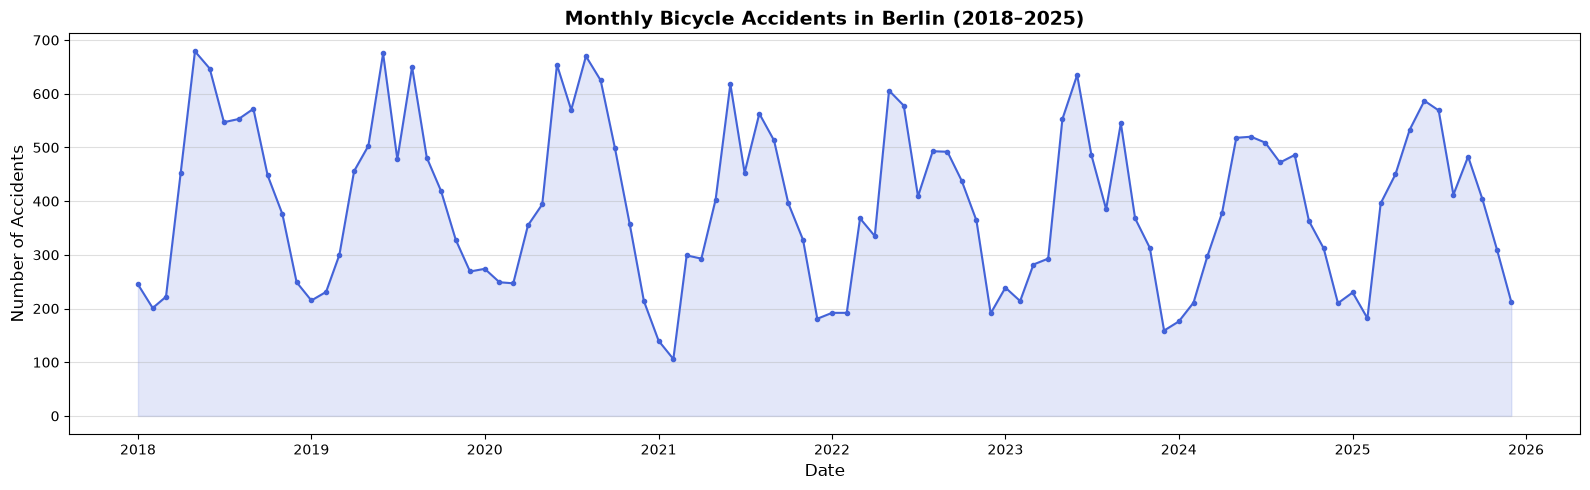

        date  accident_count
0 2018-01-01             245
1 2018-02-01             201
2 2018-03-01             222
3 2018-04-01             453
4 2018-05-01             679


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Year + Month to datetime format (defaulting to the 1st of each month)
df_berlin_rad_final['date'] = pd.to_datetime(
    df_berlin_rad_final[['year', 'month']].assign(day=1)
)

# Aggregate monthly accident counts (Monthly Time Series)
monthly_ts = (
    df_berlin_rad_final.groupby('date')
    .size()
    .reset_index(name='accident_count')
)

# Plotting the Time Series
plt.figure(figsize=(16, 5))
plt.plot(monthly_ts['date'], monthly_ts['accident_count'], 
         color='#4363d8', linewidth=1.5, marker='o', markersize=3)
plt.fill_between(monthly_ts['date'], monthly_ts['accident_count'], 
                 alpha=0.15, color='#4363d8')

plt.title('Monthly Bicycle Accidents in Berlin (2018–2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

# Save and show plot
plt.savefig('berlin_accidents_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# Display first few rows of the aggregated dataset
print(monthly_ts.head())

### 3.2 Accidents by Month & Year

Yearly comparison reveals consistent summer peaks (May–August) across all years, confirming that accident frequency is strongly driven by cycling season rather than year-over-year changes.


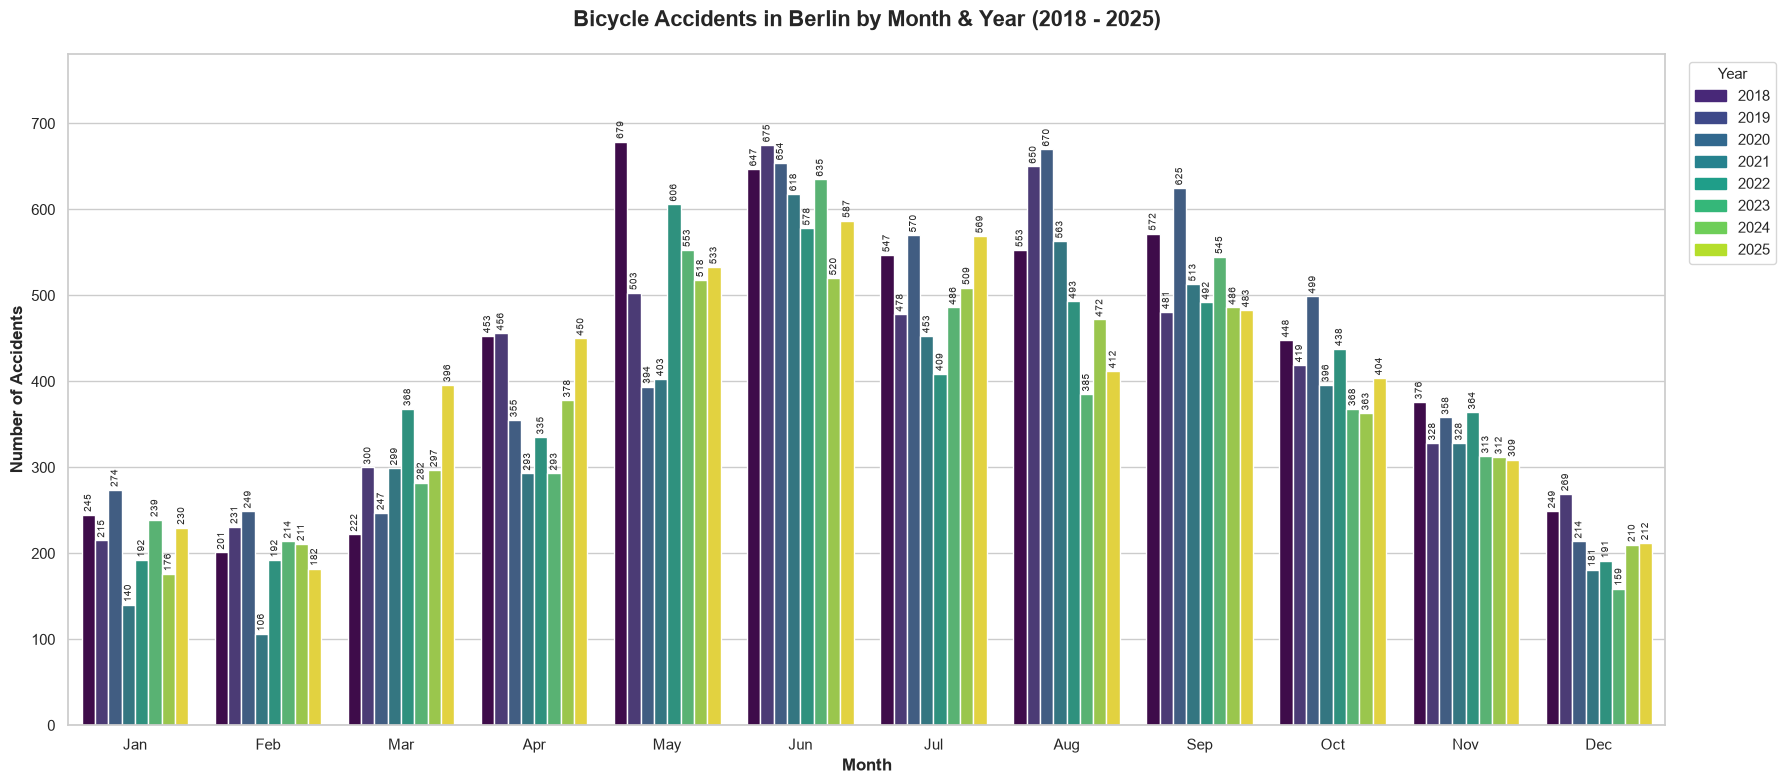

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch # Manuel lejant için gerekli

# 1. DATA CLEANING & YEAR CONVERSION
df_plot = df_berlin_rad_final.copy()

# Ensure year is strictly integer (converts string, float .0, etc.)
df_plot["year"] = pd.to_numeric(df_plot["year"], errors='coerce').fillna(0).astype(int)

# Map month numbers to month names
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_names = {i + 1: name for i, name in enumerate(month_order)}
df_plot["month_name"] = df_plot["month"].map(month_names)

# 2. GROUP DATA BY YEAR AND MONTH
monthly_yearly = (
    df_plot.groupby(["year", "month_name"])
    .size()
    .reset_index(name="accident_count")
)

# 3. EXPLICIT YEAR RANGE (2018 through 2025 - All 8 Years)
all_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Reindex grid to guarantee all 8 years and 12 months are present
full_index = pd.MultiIndex.from_product(
    [all_years, month_order], names=["year", "month_name"]
)
monthly_yearly = (
    monthly_yearly.set_index(["year", "month_name"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# 4. PLOT CONFIGURATION (Removed Seaborn Legend here)
plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=monthly_yearly,
    x="month_name",
    y="accident_count",
    hue="year",
    order=month_order,
    hue_order=all_years,
    palette="viridis",
    legend=False # Tell Seaborn to not draw its automatic legend
)

# 5. DATA LABELS ON BARS (Hides 0s)
for container in ax.containers:
    labels = [
        f"{int(v)}" if (v > 0 and not np.isnan(v)) else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7, rotation=90)

# 6. TITLES AND LABELS
plt.title(
    "Bicycle Accidents in Berlin by Month & Year (2018 - 2025)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Month", fontsize=12, fontweight="bold")
plt.ylabel("Number of Accidents", fontsize=12, fontweight="bold")

# 7. MANUALLY CREATE AND ADD THE LEGEND (Fix for Missing Years)
# First, generate the color map dynamically based on the number of years
viridis_colors = sns.color_palette("viridis", len(all_years))

# Create a list of 'Patch' objects (small color squares) with their labels
legend_patches = [
    Patch(color=viridis_colors[i], label=str(year))
    for i, year in enumerate(all_years)
]

# Add this manual legend to the plot in the same position
ax.legend(
    handles=legend_patches,
    title="Year",
    title_fontsize="11",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.ylim(0, monthly_yearly["accident_count"].max() * 1.15)
plt.tight_layout()

# Save & Display
plt.savefig("berlin_accidents_by_month_year_fixed_legend.png", dpi=300)
plt.show()

### 3.3 Temporal Dynamics: Day of Week & Hourly Peak Analysis
The day-by-hour accident heatmap indicates distinct rush-hour clusters on weekdays (07:00–09:00 and 15:00–18:00), corresponding to daily commuter routes. Conversely, weekend distribution shifts toward mid-day hours, highlighting a clear transition from functional commuting hazards to leisure riding patterns.

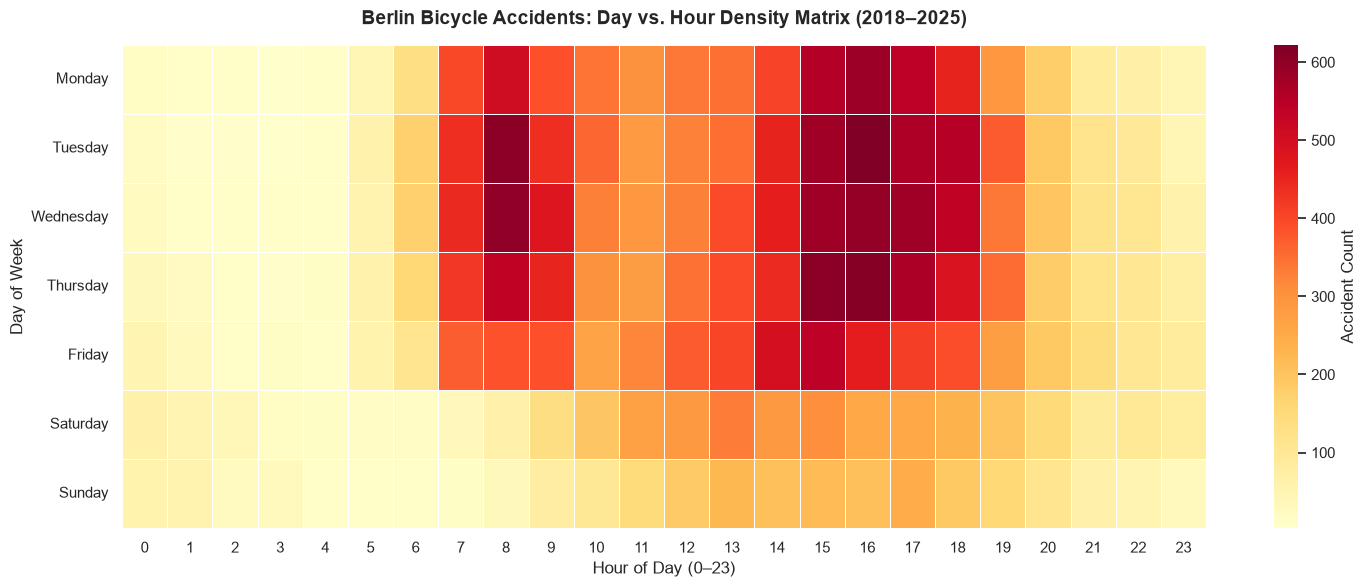

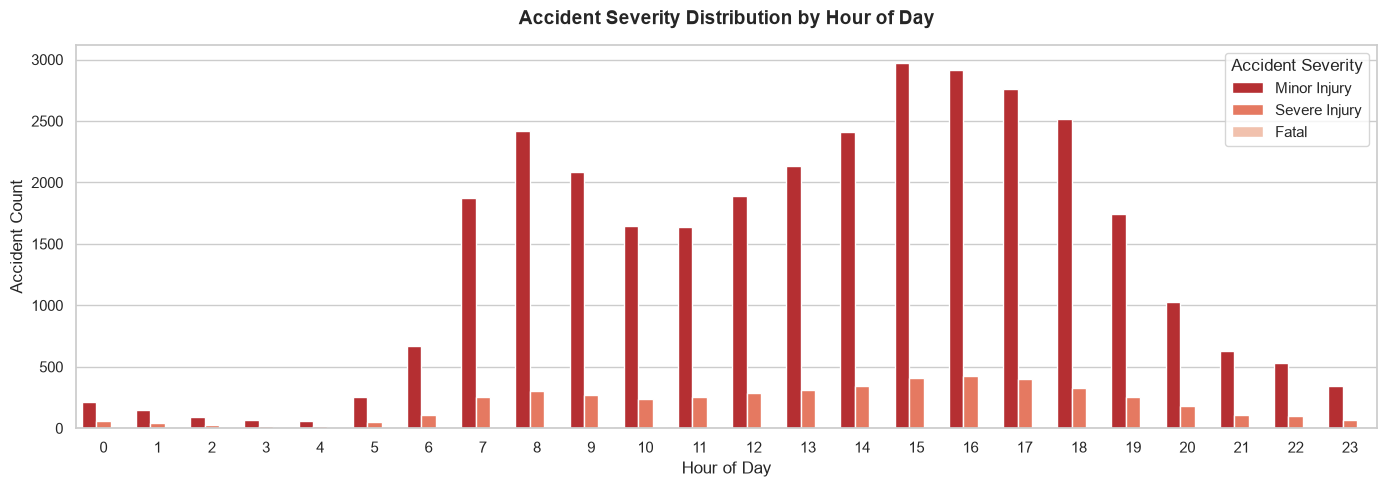

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ---------------------------------------------------------
# 1. ACCIDENT DENSITY HEATMAP (DAY OF WEEK x HOUR OF DAY)
# ---------------------------------------------------------
# Define logical ordering for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create pivot table (Rows: Days, Columns: Hours)
heatmap_data = df_berlin_rad_final.pivot_table(
    index='day_label', 
    columns='hour', 
    values='year', 
    aggfunc='count'
).reindex(day_order)

plt.figure(figsize=(15, 6))
sns.heatmap(
    heatmap_data, 
    cmap="YlOrRd", 
    annot=False, 
    linewidths=.5, 
    cbar_kws={'label': 'Accident Count'}
)

plt.title('Berlin Bicycle Accidents: Day vs. Hour Density Matrix (2018–2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. ACCIDENT COUNT AND SEVERITY DISTRIBUTION BY HOUR
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
sns.countplot(
    data=df_berlin_rad_final, 
    x='hour', 
    hue='severity_label', 
    palette='Reds_r'
)

plt.title('Accident Severity Distribution by Hour of Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Accident Count', fontsize=12)
plt.legend(title='Accident Severity', labels=['Minor Injury', 'Severe Injury', 'Fatal'])
plt.tight_layout()
plt.show()

---
## 4. Collision Partner Analysis <a id='4-collision'></a>

Each accident record flags which vehicle types were involved alongside the bicycle. We classify accidents by their collision partner to understand the primary risk sources.


                             collision_type  count  percentage
0                             Bicycle + Car  25736        67.8
1                              Bicycle Only   8317        21.9
2                      Bicycle + Pedestrian   2330         6.1
3                           Bicycle + Truck    733         1.9
4                      Bicycle + Motorcycle    653         1.7
5                Bicycle + Car + Pedestrian     94         0.2
6                Bicycle + Car + Motorcycle     44         0.1
7                     Bicycle + Car + Truck     31         0.1
8         Bicycle + Pedestrian + Motorcycle      4         0.0
9   Bicycle + Car + Pedestrian + Motorcycle      3         0.0
10             Bicycle + Motorcycle + Truck      1         0.0
11       Bicycle + Car + Motorcycle + Truck      1         0.0
12             Bicycle + Pedestrian + Truck      1         0.0


/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_4377/195485638.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/zy/dzt007ld56g78tf5yy7d_gh80000gn/T/ipykernel_4377/195485638.py:36: UserWarning: 
The palette list has fewer values (8) than needed (13) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


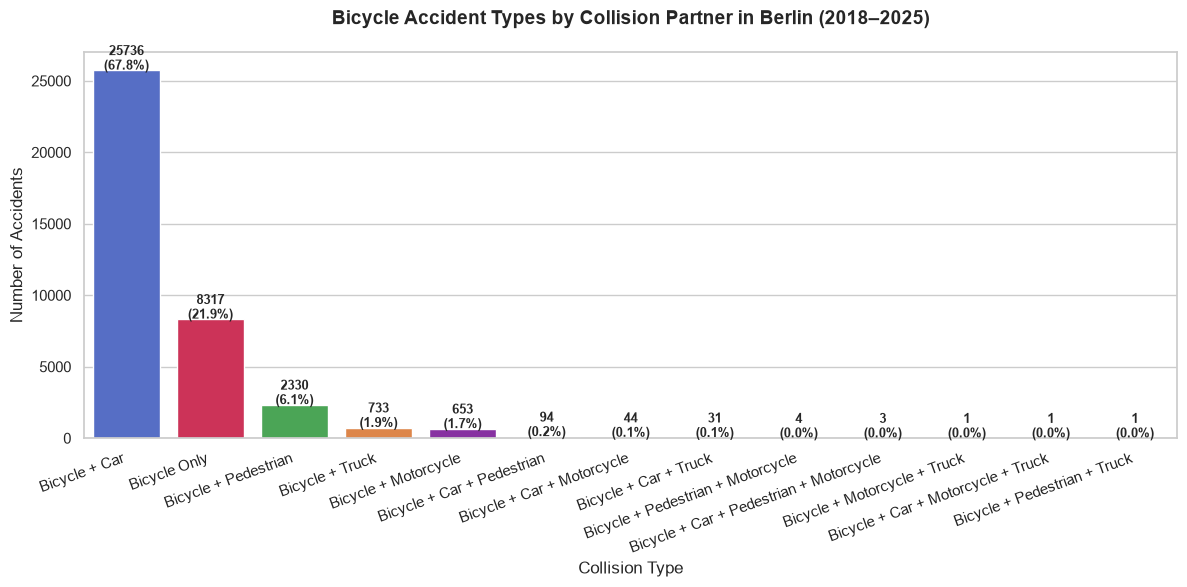

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#  1. Create a combination column
def get_combination(row):
    others = []
    if row['is_car'] == 1:
        others.append('Car')
    if row['is_pedestrian'] == 1:
        others.append('Pedestrian')
    if row['is_motorcycle'] == 1:
        others.append('Motorcycle')
    if row['is_truck'] == 1:
        others.append('Truck')
    if not others:
        return 'Bicycle Only'
    return 'Bicycle + ' + ' + '.join(others)

df_berlin_rad_final['collision_type'] = df_berlin_rad_final.apply(get_combination, axis=1)

# 2. Distribution
combo_counts = (
    df_berlin_rad_final['collision_type']
    .value_counts()
    .reset_index()
)
combo_counts.columns = ['collision_type', 'count']
combo_counts['percentage'] = (combo_counts['count'] / len(df_berlin_rad_final) * 100).round(1)

print(combo_counts.to_string())

# 3. Chart
plt.figure(figsize=(12, 6))
colors = ['#4363d8','#e6194b','#3cb44b','#f58231','#911eb4','#42d4f4','#f032e6','#bfef45']

ax = sns.barplot(
    data=combo_counts,
    x='collision_type',
    y='count',
    palette=colors[:len(combo_counts)]
)

# Write percentage and count
for i, row in combo_counts.iterrows():
    ax.text(i, row['count'] + 50, 
            f"{row['count']}\n({row['percentage']}%)", 
            ha='center', fontsize=9, fontweight='bold')

plt.title('Bicycle Accident Types by Collision Partner in Berlin (2018–2025)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Collision Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('berlin_collision_types.png', dpi=300, bbox_inches='tight')
plt.show()

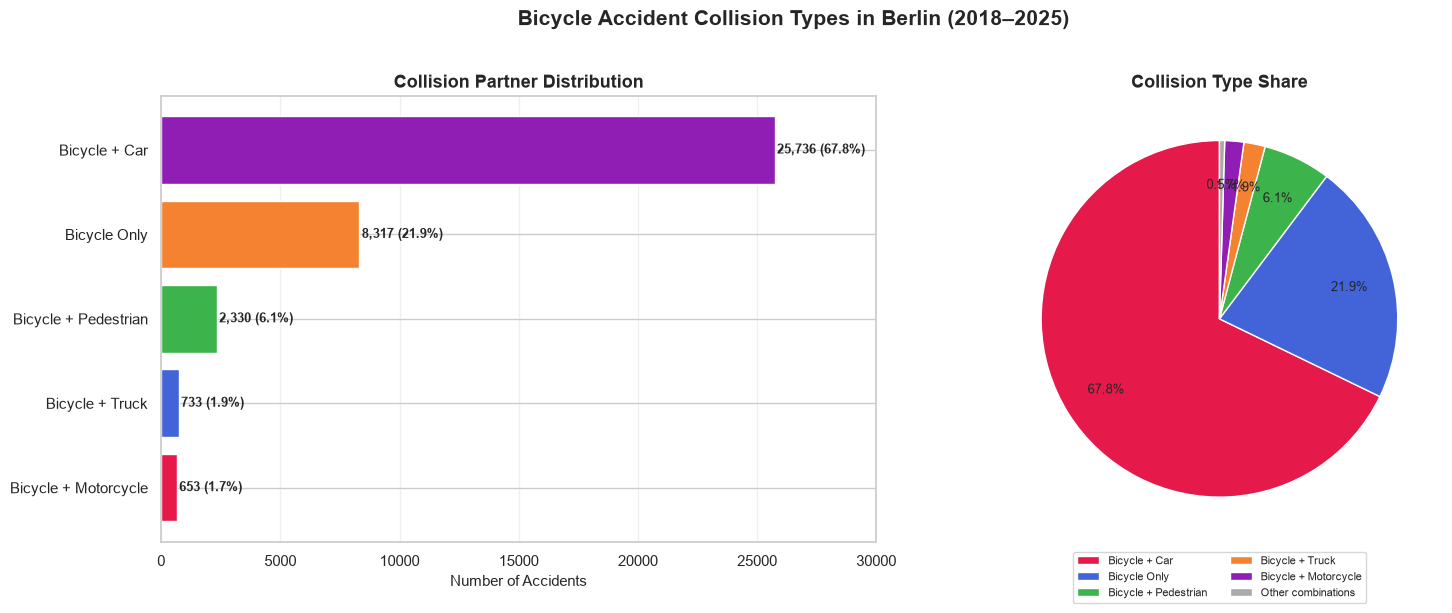

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep main combinations only (>0.5%)
combo_main = combo_counts[combo_counts['percentage'] >= 0.5].copy()
combo_rest = combo_counts[combo_counts['percentage'] < 0.5]['count'].sum()

# colors
colors = ['#e6194b','#4363d8','#3cb44b','#f58231','#911eb4']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart
ax1 = axes[0]
bars = ax1.barh(combo_main['collision_type'][::-1], 
                combo_main['count'][::-1], 
                color=colors[:len(combo_main)])
for bar, (_, row) in zip(bars, combo_main[::-1].iterrows()):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"{row['count']:,} ({row['percentage']}%)",
             va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Number of Accidents', fontsize=11)
ax1.set_title('Collision Partner Distribution', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 30000)
ax1.grid(axis='x', alpha=0.3)

# Right: Pie chart
ax2 = axes[1]
pie_data = list(combo_main['count']) + [combo_rest]
pie_labels = list(combo_main['collision_type']) + ['Other combinations']
pie_colors = colors + ['#aaaaaa']
wedges, texts, autotexts = ax2.pie(
    pie_data,
    labels=None,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax2.legend(pie_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize=8, ncol=2)
ax2.set_title('Collision Type Share', fontsize=13, fontweight='bold')

plt.suptitle('Bicycle Accident Collision Types in Berlin (2018–2025)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_collision_types.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.1 Solo Crashes — Road & Light Conditions

**Hypothesis:** Bicycle-only crashes (no other vehicle) occur more often on wet or icy roads.

We test this by comparing road and light conditions between solo crashes and the full accident dataset.


In [13]:
## Filter: Bicycle Only accidents (no other vehicle involved)
df_bike_only = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle Only']

print(f"Bicycle Only accidents: {len(df_bike_only)}")

print(f"\nRoad conditions distribution:")
print(df_bike_only['road_label'].value_counts())

print(f"\nAs percentage:")
print((df_bike_only['road_label'].value_counts() / len(df_bike_only) * 100).round(1))

print("\n--- Comparison: All accidents ---")
print((df_berlin_rad_final['road_label'].value_counts() / len(df_berlin_rad_final) * 100).round(1))

Bicycle Only accidents: 8317

Road conditions distribution:
road_label
dry         6876
wet_damp    1338
ice_snow     103
Name: count, dtype: int64

As percentage:
road_label
dry         82.7
wet_damp    16.1
ice_snow     1.2
Name: count, dtype: float64

--- Comparison: All accidents ---
road_label
dry         82.1
wet_damp    17.4
ice_snow     0.6
Name: count, dtype: float64


collision_type
Bicycle + Car                              25736
Bicycle Only                                8317
Bicycle + Pedestrian                        2330
Bicycle + Truck                              733
Bicycle + Motorcycle                         653
Bicycle + Car + Pedestrian                    94
Bicycle + Car + Motorcycle                    44
Bicycle + Car + Truck                         31
Bicycle + Pedestrian + Motorcycle              4
Bicycle + Car + Pedestrian + Motorcycle        3
Bicycle + Motorcycle + Truck                   1
Bicycle + Car + Motorcycle + Truck             1
Bicycle + Pedestrian + Truck                   1
Name: count, dtype: int64 

Ice/snow share — solo: 1.2% (n=103) | other: 0.4% (n=107)
Ratio: 3.43x | z=9.53, p=0.0000


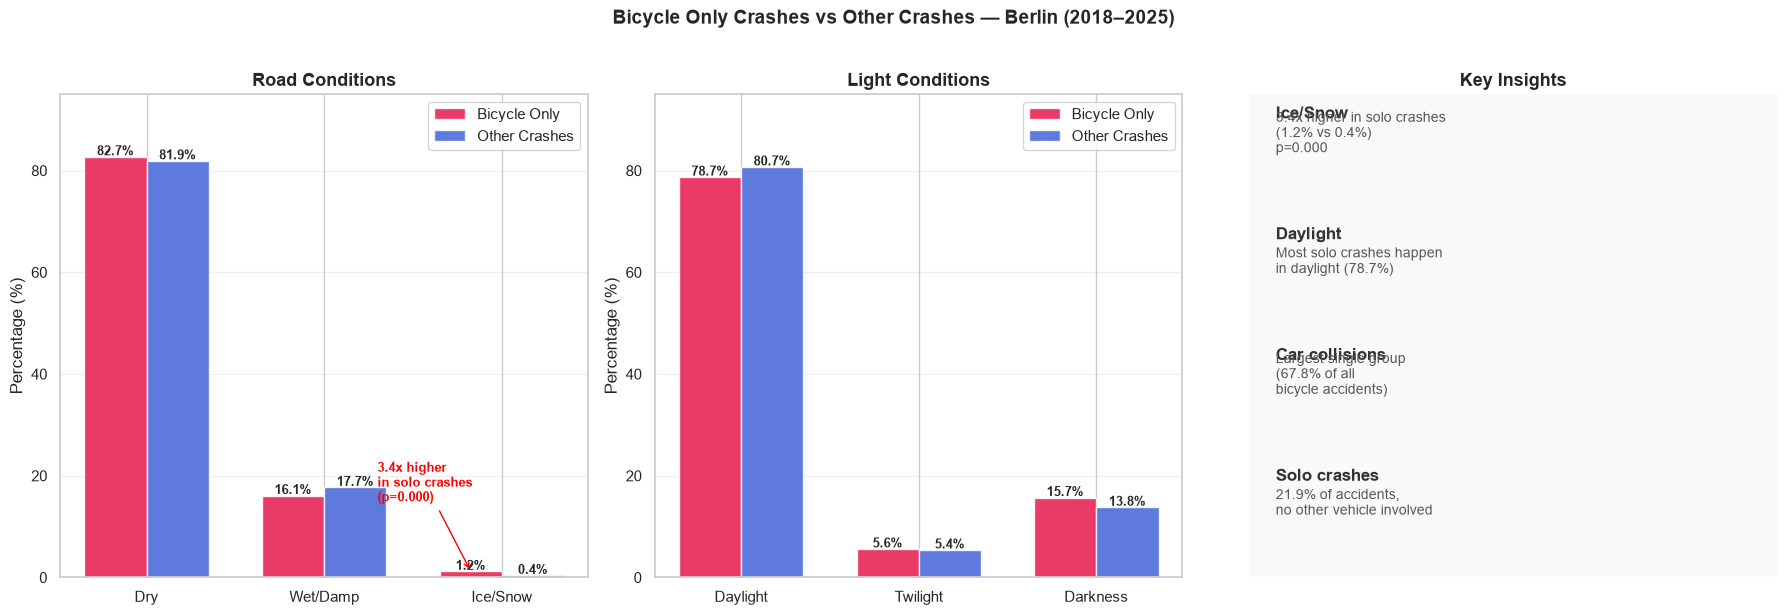

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import math

# ── Sanity check: confirm the collision_type categories exist as expected ──
print(df_berlin_rad_final['collision_type'].value_counts(), '\n')

SOLO_LABEL = 'Bicycle Only'
solo     = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == SOLO_LABEL]
non_solo = df_berlin_rad_final[df_berlin_rad_final['collision_type'] != SOLO_LABEL]

assert len(solo) > 0, f"No rows matched collision_type == '{SOLO_LABEL}'"


def category_share(frame, col, order):
    """Percentage share per category, returned in a fixed category order."""
    return (
        frame[col]
        .value_counts(normalize=True)
        .mul(100)
        .reindex(order)
        .fillna(0)
        .round(1)
        .tolist()
    )


def two_proportion_ztest(successes, totals):
    """Two-sided z-test for the difference between two proportions."""
    x1, x2 = successes
    n1, n2 = totals
    p_pool = (x1 + x2) / (n1 + n2)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (x1 / n1 - x2 / n2) / se
    # Two-sided p-value from the normal approximation
    p = math.erfc(abs(z) / math.sqrt(2))
    return z, p


# ── Category orders (fixed, never rely on value_counts ordering) ──
road_order  = ['dry', 'wet_damp', 'ice_snow']
light_order = ['daylight', 'twilight', 'darkness']

categories = ['Dry', 'Wet/Damp', 'Ice/Snow']
light_cats = ['Daylight', 'Twilight', 'Darkness']

# Solo crashes are compared against NON-solo crashes.
# Comparing them against the full dataset would be biased, because
# solo crashes are themselves a subset of that dataset.
solo_road  = category_share(solo,     'road_label',  road_order)
other_road = category_share(non_solo, 'road_label',  road_order)
solo_light  = category_share(solo,     'light_label', light_order)
other_light = category_share(non_solo, 'light_label', light_order)

# ── Statistical check for the ice/snow claim ──
ice_counts = [(solo['road_label'] == 'ice_snow').sum(),
              (non_solo['road_label'] == 'ice_snow').sum()]
ice_totals = [len(solo), len(non_solo)]
ice_z, ice_p = two_proportion_ztest(ice_counts, ice_totals)
ice_ratio = (ice_counts[0] / ice_totals[0]) / (ice_counts[1] / ice_totals[1])

print(f"Ice/snow share — solo: {solo_road[2]}% (n={ice_counts[0]}) | "
      f"other: {other_road[2]}% (n={ice_counts[1]})")
print(f"Ratio: {ice_ratio:.2f}x | z={ice_z:.2f}, p={ice_p:.4f}")

SIGNIFICANCE = 0.05
ice_is_significant = ice_p < SIGNIFICANCE

# ── Figures used in the insight card, all derived from the data ──
solo_share    = len(solo) / len(df_berlin_rad_final) * 100
daylight_solo = solo_road_daylight = solo_light[0]
car_share     = (
    (df_berlin_rad_final['collision_type'] == 'Bicycle + Car').mean() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(categories))
width = 0.35


def grouped_bars(ax, labels, series_a, series_b, title, ticks):
    """Draw a two-series grouped bar chart with value labels."""
    pos = np.arange(len(ticks))
    bars_a = ax.bar(pos - width / 2, series_a, width,
                    label='Bicycle Only', color='#e6194b', alpha=0.85)
    bars_b = ax.bar(pos + width / 2, series_b, width,
                    label='Other Crashes', color='#4363d8', alpha=0.85)
    for bar in list(bars_a) + list(bars_b):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_xticks(pos)
    ax.set_xticklabels(ticks)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 95)
    ax.grid(axis='y', alpha=0.3)
    return bars_a, bars_b


# 1. Road conditions
grouped_bars(axes[0], categories, solo_road, other_road,
             'Road Conditions', categories)

# Annotate the ice/snow difference only if it survives a significance test.
if ice_is_significant:
    axes[0].annotate(
        f'{ice_ratio:.1f}x higher\nin solo crashes\n(p={ice_p:.3f})',
        xy=(2 - width / 2, solo_road[2]), xytext=(1.3, 15),
        arrowprops=dict(arrowstyle='->', color='red'),
        color='red', fontsize=9, fontweight='bold',
    )

# 2. Light conditions
grouped_bars(axes[1], light_cats, solo_light, other_light,
             'Light Conditions', light_cats)

# 3. Summary insight card
ax3 = axes[2]
ax3.axis('off')
ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True,
              color='#f8f9fa', transform=ax3.transAxes, zorder=0))

ice_verdict = (
    f"{ice_ratio:.1f}x higher in solo crashes\n"
    f"({solo_road[2]}% vs {other_road[2]}%)\n"
    f"p={ice_p:.3f}"
    if ice_is_significant
    else f"No significant difference\n({solo_road[2]}% vs {other_road[2]}%)\n"
         f"p={ice_p:.3f}"
)

insights = [
    ("Ice/Snow", ice_verdict),
    ("Daylight", f"Most solo crashes happen\nin daylight ({solo_light[0]}%)"),
    ("Car collisions", f"Largest single group\n({car_share:.1f}% of all\nbicycle accidents)"),
    ("Solo crashes", f"{solo_share:.1f}% of accidents,\nno other vehicle involved"),
]

y_pos = 0.95
for heading, detail in insights:
    ax3.text(0.05, y_pos, heading, transform=ax3.transAxes,
             fontsize=12, fontweight='bold', color='#333333')
    ax3.text(0.05, y_pos - 0.07, detail, transform=ax3.transAxes,
             fontsize=10, color='#555555')
    y_pos -= 0.25

ax3.set_title('Key Insights', fontsize=13, fontweight='bold')

plt.suptitle(f'Bicycle Only Crashes vs Other Crashes — Berlin (2018–2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_solo_crash_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Temporal Analysis <a id='5-temporal'></a>

### 5.1 Bicycle vs Car Accidents by Hour

We focus on the most common collision type (Bicycle + Car, 67.8%) and examine at which hours of the day accidents peak. Values represent **yearly averages** to account for differences in data volume across years.


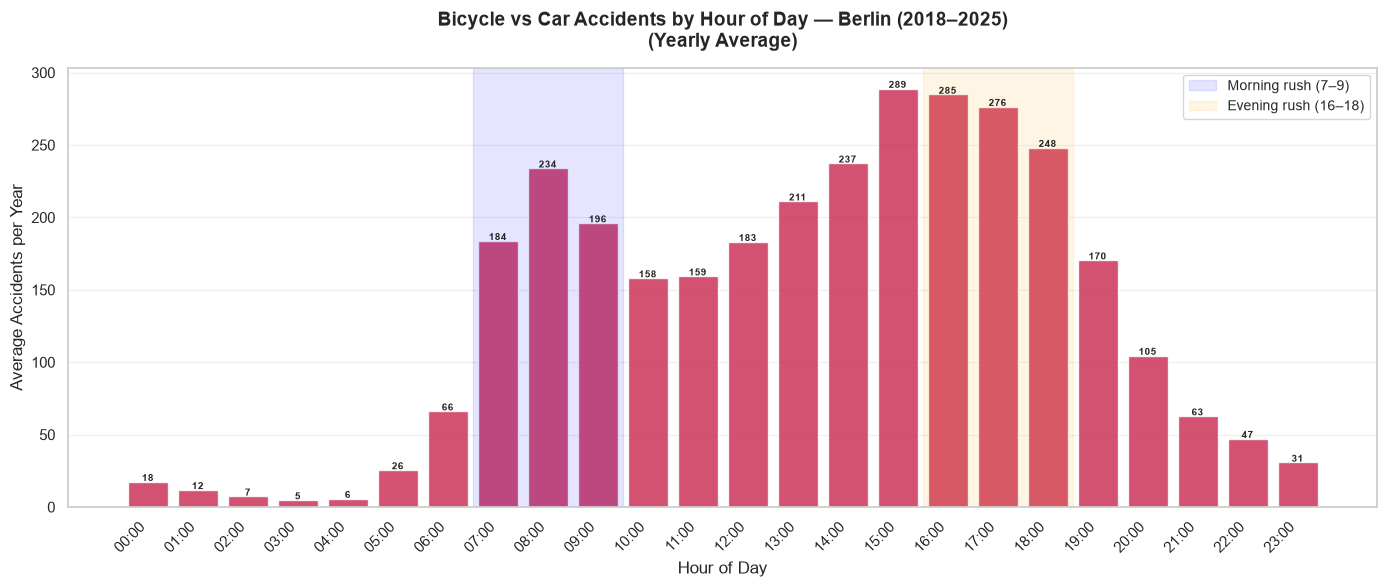

Top 5 most dangerous hours (yearly average):
 hour  count
   15  289.0
   16  284.9
   17  276.5
   18  248.2
   14  237.4


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter: Bicycle + Car accidents only
df_bike_car = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle + Car']

# Yearly average per hour
hourly_avg = (df_bike_car.groupby(['year', 'hour'])
              .size()
              .reset_index(name='count')
              .groupby('hour')['count']
              .mean()
              .round(1)
              .reset_index())

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=hourly_avg, x='hour', y='count', color='#e6194b', alpha=0.85)

# Add value labels on bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=7.5, fontweight='bold')

# Highlight rush hours
ax.axvspan(6.5, 9.5, alpha=0.1, color='blue', label='Morning rush (7–9)')
ax.axvspan(15.5, 18.5, alpha=0.1, color='orange', label='Evening rush (16–18)')

plt.title('Bicycle vs Car Accidents by Hour of Day — Berlin (2018–2025)\n(Yearly Average)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.xticks(range(24), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('berlin_bike_car_by_hour_avg.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 most dangerous hours (yearly average):")
print(hourly_avg.nlargest(5, 'count').to_string(index=False))

### 5.2 Accidents by Day of Week

**Hypothesis 1 — Monday effect:** Cyclists are less alert at the start of the week.  
**Hypothesis 2 — Friday effect:** Impatience before the weekend leads to more risk-taking.


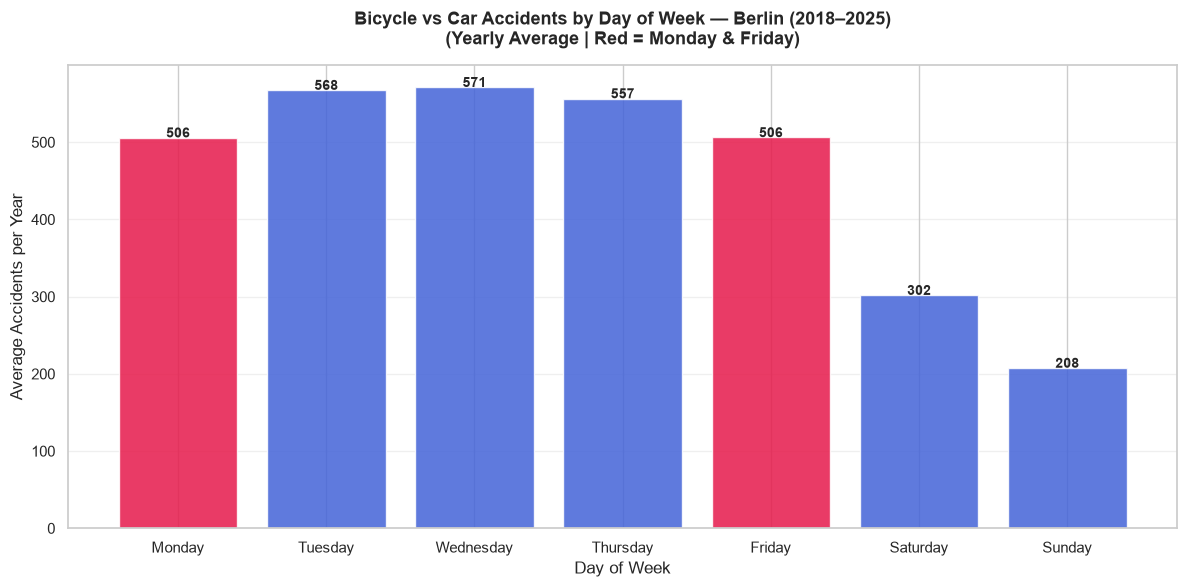

Average accidents by day of week:
 day_name  count
   Monday  505.9
  Tuesday  567.5
Wednesday  571.2
 Thursday  556.6
   Friday  506.2
 Saturday  301.9
   Sunday  207.6


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Day order and names (Germany: 1=Sunday, 2=Monday, ..., 7=Saturday)
day_order = [2, 3, 4, 5, 6, 7, 1]  # Monday → Sunday
day_names = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
             5:'Thursday', 6:'Friday', 7:'Saturday'}

# Bicycle + Car — yearly average per day
daily_avg = (df_bike_car.groupby(['year', 'day_of_week'])
             .size()
             .reset_index(name='count')
             .groupby('day_of_week')['count']
             .mean()
             .round(1)
             .reset_index())

daily_avg['day_name'] = daily_avg['day_of_week'].map(day_names)
daily_avg['day_name'] = pd.Categorical(
    daily_avg['day_name'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)
daily_avg = daily_avg.sort_values('day_name')

# Highlight Monday & Friday in red
colors = ['#e6194b' if d in ['Friday', 'Monday'] else '#4363d8'
          for d in daily_avg['day_name']]

plt.figure(figsize=(12, 6))
ax = plt.bar(daily_avg['day_name'], daily_avg['count'], color=colors, alpha=0.85)

# Add value labels on bars
for bar in ax:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Bicycle vs Car Accidents by Day of Week — Berlin (2018–2025)\n(Yearly Average | Red = Monday & Friday)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('berlin_bike_car_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average accidents by day of week:")
print(daily_avg[['day_name','count']].to_string(index=False))

### 5.3 Mid-Week Deep Dive (Tue–Thu)

Tuesday, Wednesday and Thursday consistently show the highest accident counts. We investigate whether this is driven by time-of-day patterns, severity differences, or light conditions.


In [19]:
# Hourly distribution: Tue–Wed–Thu vs Mon–Fri
df_bike_car['day_name'] = df_bike_car['day_of_week'].map(day_names)

mid_week   = df_bike_car[df_bike_car['day_name'].isin(['Tuesday','Wednesday','Thursday'])]
other_week = df_bike_car[df_bike_car['day_name'].isin(['Monday','Friday'])]

hourly_mid   = mid_week.groupby('hour').size() / 3    # average per day
hourly_other = other_week.groupby('hour').size() / 2

print("Hourly difference (Tue–Wed–Thu vs Mon–Fri):")
diff = (hourly_mid - hourly_other).round(1)
print(diff.sort_values(ascending=False).head(10))

Hourly difference (Tue–Wed–Thu vs Mon–Fri):
hour
8     93.7
18    71.8
17    60.2
7     56.0
16    55.5
19    46.7
15    40.8
9     40.0
6     30.2
10    11.5
dtype: float64


In [18]:
severity_by_day = df_bike_car.groupby(['day_name','severity_label']).size().unstack(fill_value=0)
severity_by_day['serious_rate'] = (severity_by_day['serious_injury'] / 
                                    severity_by_day.sum(axis=1) * 100).round(1)
print(severity_by_day[['serious_injury','fatal','serious_rate']])

severity_label  serious_injury  fatal  serious_rate
day_name                                           
Friday                     437      2          10.8
Monday                     398      6           9.8
Saturday                   288      3          11.9
Sunday                     224      2          13.5
Thursday                   449      4          10.1
Tuesday                    441      2           9.7
Wednesday                  461      4          10.1


---
## 6. District Risk Analysis <a id='6-district'></a>

We analyse accident counts and serious injury rates across Berlin's 12 districts. 

> **Key insight:** Total accident count and injury severity rate tell different stories — a district with many accidents is not necessarily the most dangerous one.


In [20]:
# District names (Berlin district codes)
district_names = {
    1: 'Mitte', 2: 'Friedrichshain-Kreuzberg', 3: 'Pankow',
    4: 'Charlottenburg-Wilmersdorf', 5: 'Spandau', 6: 'Steglitz-Zehlendorf',
    7: 'Tempelhof-Schöneberg', 8: 'Neukölln', 9: 'Treptow-Köpenick',
    10: 'Marzahn-Hellersdorf', 11: 'Lichtenberg', 12: 'Reinickendorf'
}

df_berlin_rad_final['district_name'] = df_berlin_rad_final['district_code'].map(district_names)

district_stats = (df_berlin_rad_final.groupby('district_name')
                  .agg(
                      total_accidents=('accident_severity', 'count'),
                      serious_fatal=('severity_label', lambda x: (x.isin(['serious_injury','fatal'])).sum())
                  )
                  .assign(serious_rate=lambda x: (x['serious_fatal']/x['total_accidents']*100).round(1))
                  .sort_values('total_accidents', ascending=False)
                  .reset_index())

print(district_stats.to_string(index=False))

             district_name  total_accidents  serious_fatal  serious_rate
                     Mitte             7338            781          10.6
  Friedrichshain-Kreuzberg             5124            552          10.8
                    Pankow             4205            578          13.7
Charlottenburg-Wilmersdorf             3983            494          12.4
      Tempelhof-Schöneberg             3001            411          13.7
          Treptow-Köpenick             2875            459          16.0
       Steglitz-Zehlendorf             2548            426          16.7
                  Neukölln             2360            231           9.8
               Lichtenberg             2032            296          14.6
             Reinickendorf             1674            249          14.9
       Marzahn-Hellersdorf             1419            236          16.6
                   Spandau             1389            217          15.6


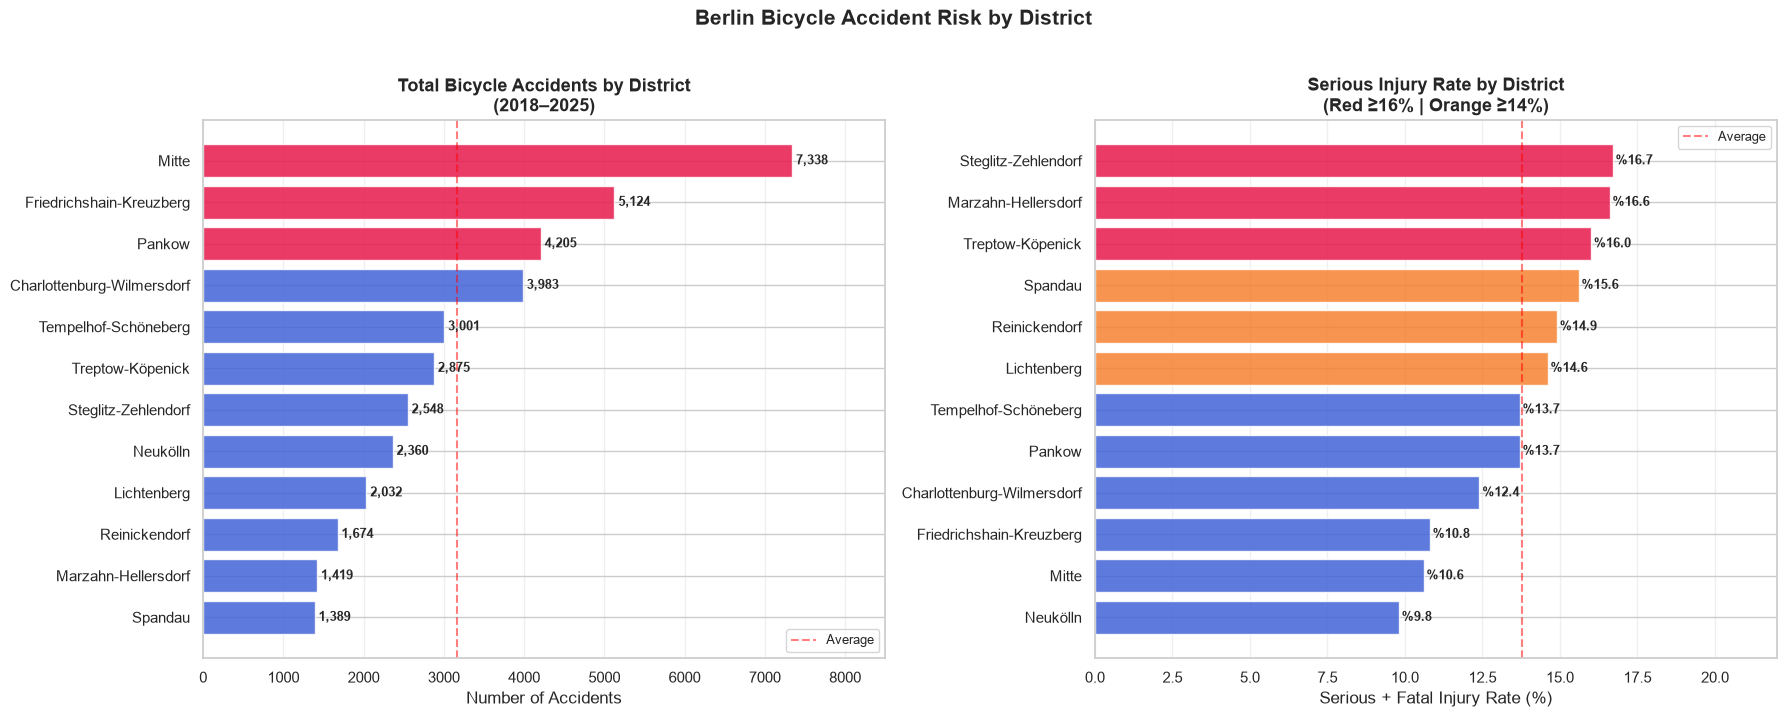

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Total Bicycle Accidents by District
district_sorted = district_stats.sort_values('total_accidents', ascending=True)
colors_total = ['#e6194b' if d in ['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow'] 
                else '#4363d8' for d in district_sorted['district_name']]

axes[0].barh(district_sorted['district_name'], 
             district_sorted['total_accidents'], 
             color=colors_total, alpha=0.85)
for i, (val, name) in enumerate(zip(district_sorted['total_accidents'], 
                                     district_sorted['district_name'])):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Bicycle Accidents by District\n(2018–2025)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
axes[0].set_xlim(0, 8500)
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=district_stats['total_accidents'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[0].legend(fontsize=9)

# Right: Serious Injury Rate by District
district_severity = district_stats.sort_values('serious_rate', ascending=True)
colors_severity = ['#e6194b' if r >= 16.0 else '#f58231' if r >= 14.0 
                   else '#4363d8' for r in district_severity['serious_rate']]

axes[1].barh(district_severity['district_name'], 
             district_severity['serious_rate'], 
             color=colors_severity, alpha=0.85)
for i, val in enumerate(district_severity['serious_rate']):
    axes[1].text(val + 0.1, i, f'%{val}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Serious Injury Rate by District\n(Red ≥16% | Orange ≥14%)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Serious + Fatal Injury Rate (%)')
axes[1].set_xlim(0, 22)
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=district_stats['serious_rate'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[1].legend(fontsize=9)

plt.suptitle('Berlin Bicycle Accident Risk by District', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('berlin_district_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Geospatial Heatmap <a id='7-heatmap'></a>

An interactive heatmap weighted by accident severity (Fatal ×3 / Serious ×2 / Minor ×1) reveals the spatial distribution of high-risk zones across Berlin.


In [25]:
import folium
from folium.plugins import HeatMap
import pandas as pd

# 1. FIX AND CLEAN COORDINATES
df_berlin_rad_final["latitude"] = (
    df_berlin_rad_final["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df_berlin_rad_final["longitude"] = (
    df_berlin_rad_final["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

geo_data = df_berlin_rad_final[["latitude", "longitude"]].dropna().copy()

# 2. FIND ACCIDENT HOTSPOTS (Grid Method)
# Rounding to 3 decimal places represents ~100m grid cells
geo_data["lat_grid"] = geo_data["latitude"].round(3)
geo_data["lon_grid"] = geo_data["longitude"].round(3)

# Top 10 most dangerous locations
hotspots = (
    geo_data.groupby(["lat_grid", "lon_grid"])
    .size()
    .reset_index(name="accident_count")
    .sort_values(by="accident_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Most Dangerous Locations:")
print(hotspots)

# 3. CREATE MAP
berlin_coords = [52.5200, 13.4050]
m = folium.Map(location=berlin_coords, zoom_start=12, tiles="OpenStreetMap")

# 4. ADD HEATMAP LAYER
heat_data = geo_data[["latitude", "longitude"]].values.tolist()
HeatMap(heat_data, radius=9, blur=10, max_zoom=13, min_opacity=0.3).add_to(m)

# 5. ADD MARKERS FOR TOP HOTSPOTS
for idx, row in hotspots.iterrows():
    # Top 3 locations in red, rest in orange
    color = "red" if idx < 3 else "orange"

    folium.Marker(
        location=[row["lat_grid"], row["lon_grid"]],
        popup=f"<b>Rank: #{idx+1}</b><br>Accidents: {row['accident_count']}",
        tooltip=f"Hotspot #{idx+1} ({row['accident_count']} accidents)",
        icon=folium.Icon(color=color, icon="warning", prefix="fa"),
    ).add_to(m)

# Save map
m.save("berlin_bike_accidents_heatmap.html")
m

Top 10 Most Dangerous Locations:
   lat_grid  lon_grid  accident_count
0    52.516    13.454             107
1    52.525    13.420              57
2    52.504    13.410              51
3    52.503    13.447              50
4    52.493    13.388              48
5    52.501    13.442              43
6    52.516    13.381              42
7    52.539    13.424              41
8    52.504    13.411              41
9    52.517    13.441              40


---
## Next Steps

- [ ] **Feature engineering** — rush hour flag, season, weekend/weekday
- [ ] **ML model** — XGBoost classifier for accident severity prediction
- [ ] **Route risk engine** — OSMnx + NetworkX for safe route recommendation
- [ ] **Streamlit dashboard** — interactive app combining all analyses
- [ ] **Claude API integration** — natural language route explanations
